# **1. Perkenalan Dataset**


## 📌 Dataset: Heart Disease UCI

Dataset ini bersumber dari **UCI Machine Learning Repository** dan tersedia secara publik di **Kaggle**
([tautan dataset](https://www.kaggle.com/datasets/cherngs/heart-disease-cleveland-uci)).

### Deskripsi Dataset

Dataset Heart Disease UCI berisi data pasien yang dikumpulkan dari Cleveland Clinic Foundation.
Tujuan utama dataset ini adalah **memprediksi apakah seorang pasien menderita penyakit jantung atau tidak**
berdasarkan berbagai fitur medis.

### Informasi Dataset

| Atribut | Keterangan |
|---|---|
| **Sumber** | UCI ML Repository / Kaggle |
| **Jumlah Baris** | 303 sampel |
| **Jumlah Kolom** | 14 fitur |
| **Tipe Masalah** | Binary Classification |
| **Target** | `condition` (0 = Tidak Sakit, 1 = Sakit Jantung) |

### Deskripsi Fitur

| Fitur | Tipe | Keterangan |
|---|---|---|
| `age` | Numerik | Usia pasien (tahun) |
| `sex` | Kategorikal | Jenis kelamin (1=Pria, 0=Wanita) |
| `cp` | Kategorikal | Jenis nyeri dada (0-3) |
| `trestbps` | Numerik | Tekanan darah istirahat (mm Hg) |
| `chol` | Numerik | Kadar kolesterol (mg/dl) |
| `fbs` | Kategorikal | Gula darah puasa > 120 mg/dl (1=ya, 0=tidak) |
| `restecg` | Kategorikal | Hasil EKG istirahat (0-2) |
| `thalach` | Numerik | Detak jantung maksimum |
| `exang` | Kategorikal | Angina akibat olahraga (1=ya, 0=tidak) |
| `oldpeak` | Numerik | Depresi ST akibat olahraga |
| `slope` | Kategorikal | Kemiringan segmen ST puncak |
| `ca` | Numerik | Jumlah pembuluh darah utama (0-3) |
| `thal` | Kategorikal | Thalassemia (1=normal, 2=fixed defect, 3=reversible defect) |
| `condition` | Target | 0 = Tidak Sakit, 1 = Sakit Jantung |


# **2. Import Library**


Pada tahap ini, kita mengimpor seluruh pustaka Python yang dibutuhkan untuk analisis data,
visualisasi, dan pembangunan model machine learning.


In [1]:
# ==========================================
# IMPORT SEMUA LIBRARY YANG DIBUTUHKAN
# ==========================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print("✅ Seluruh library berhasil diimport!")

✅ Seluruh library berhasil diimport!


# **3. Memuat Dataset**


Dataset dimuat langsung dari URL publik GitHub (mirror dari UCI Heart Disease Cleveland dataset).
Setelah dimuat, kita periksa beberapa baris awal untuk memahami struktur data.


In [3]:
# ==========================================
# MEMUAT DATASET
# ==========================================
FILE_CANDIDATES = [
    'heart_disease_raw/raw_dataset.csv', # Pastikan path mengarah ke dalam folder raw data sesuai kriteria!
    'heart_disease_uci.csv',
    'heart.csv'
]

df = None
for fname in FILE_CANDIDATES:
    if os.path.exists(fname):
        df = pd.read_csv(fname)
        print(f"✅ Dataset berhasil dimuat dari file: {fname}")
        break

if df is None:
    raise FileNotFoundError("❌ File dataset tidak ditemukan! Pastikan dataset ada di folder heart_disease_raw")

# Menghapus kolom yang tidak diperlukan
drop_cols = ['id', 'dataset']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Binarisasi target: 0 = tidak sakit, 1 = sakit jantung
rename_map = {'thalch': 'thalach', 'num': 'condition'}
df = df.rename(columns=rename_map)
df['condition'] = (df['condition'] > 0).astype(int)

df.head()

✅ Dataset berhasil dimuat dari file: heart_disease_uci.csv


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,63,Male,typical angina,145.00,233.00,True,lv hypertrophy,150.00,False,2.30,downsloping,0.00,fixed defect,0
1,67,Male,asymptomatic,160.00,286.00,False,lv hypertrophy,108.00,True,1.50,flat,3.00,normal,1
2,67,Male,asymptomatic,120.00,229.00,False,lv hypertrophy,129.00,True,2.60,flat,2.00,reversable defect,1
3,37,Male,non-anginal,130.00,250.00,False,normal,187.00,False,3.50,downsloping,0.00,normal,0
4,41,Female,atypical angina,130.00,204.00,False,lv hypertrophy,172.00,False,1.40,upsloping,0.00,normal,0


In [4]:
# ── Informasi Tipe Data & Nilai Kosong ─────────────────────────
print("📋 Informasi Dataset:")
print("=" * 55)
df.info()


📋 Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        920 non-null    int64  
 1   sex        920 non-null    object 
 2   cp         920 non-null    object 
 3   trestbps   861 non-null    float64
 4   chol       890 non-null    float64
 5   fbs        830 non-null    object 
 6   restecg    918 non-null    object 
 7   thalach    865 non-null    float64
 8   exang      865 non-null    object 
 9   oldpeak    858 non-null    float64
 10  slope      611 non-null    object 
 11  ca         309 non-null    float64
 12  thal       434 non-null    object 
 13  condition  920 non-null    int64  
dtypes: float64(5), int64(2), object(7)
memory usage: 100.8+ KB


In [5]:
# ── Statistik Deskriptif ───────────────────────────────────────
print("📈 Statistik Deskriptif:")
df.describe()


📈 Statistik Deskriptif:


,age,trestbps,chol,thalach,oldpeak,ca,condition
count,920.00,861.00,890.00,865.00,858.00,309.00,920.00
mean,53.51,132.13,199.13,137.55,0.88,0.68,0.55
std,9.42,19.07,110.78,25.93,1.09,0.94,0.50
min,28.00,0.00,0.00,60.00,-2.60,0.00,0.00
25%,47.00,120.00,175.00,120.00,0.00,0.00,0.00
50%,54.00,130.00,223.00,140.00,0.50,0.00,1.00
75%,60.00,140.00,268.00,157.00,1.50,1.00,1.00
max,77.00,200.00,603.00,202.00,6.20,3.00,1.00


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, kita melakukan eksplorasi mendalam terhadap dataset untuk memahami:
- Distribusi setiap fitur
- Hubungan antar fitur
- Pola yang berkaitan dengan target (kondisi penyakit jantung)
- Keberadaan nilai kosong dan outlier


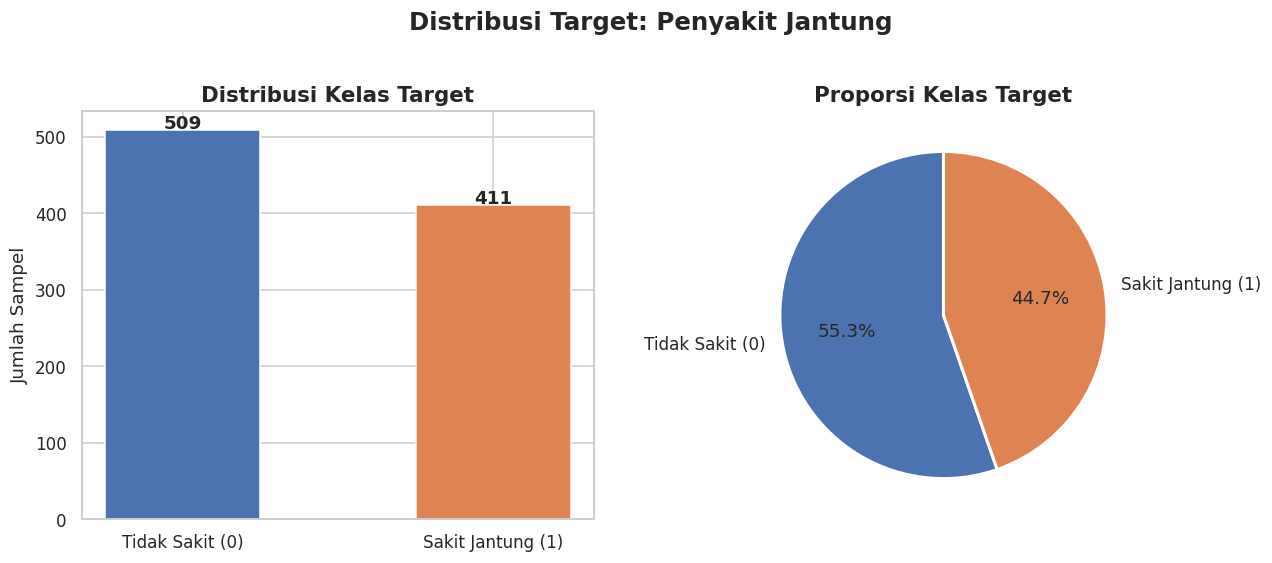


🎯 Distribusi Target:
condition
1    509
0    411

   Rasio Tidak Sakit : 44.7%
   Rasio Sakit       : 55.3%


In [6]:
# ── 4.1 Distribusi Target ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Countplot
target_counts = df['condition'].value_counts()
labels = ['Tidak Sakit (0)', 'Sakit Jantung (1)']
colors = ['#4C72B0', '#DD8452']

axes[0].bar(labels, target_counts.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Distribusi Kelas Target', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    target_counts.values,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proporsi Kelas Target', fontsize=14, fontweight='bold')

plt.suptitle('Distribusi Target: Penyakit Jantung', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n🎯 Distribusi Target:")
print(target_counts.to_string())
print(f"\n   Rasio Tidak Sakit : {target_counts[0]/len(df)*100:.1f}%")
print(f"   Rasio Sakit       : {target_counts[1]/len(df)*100:.1f}%")


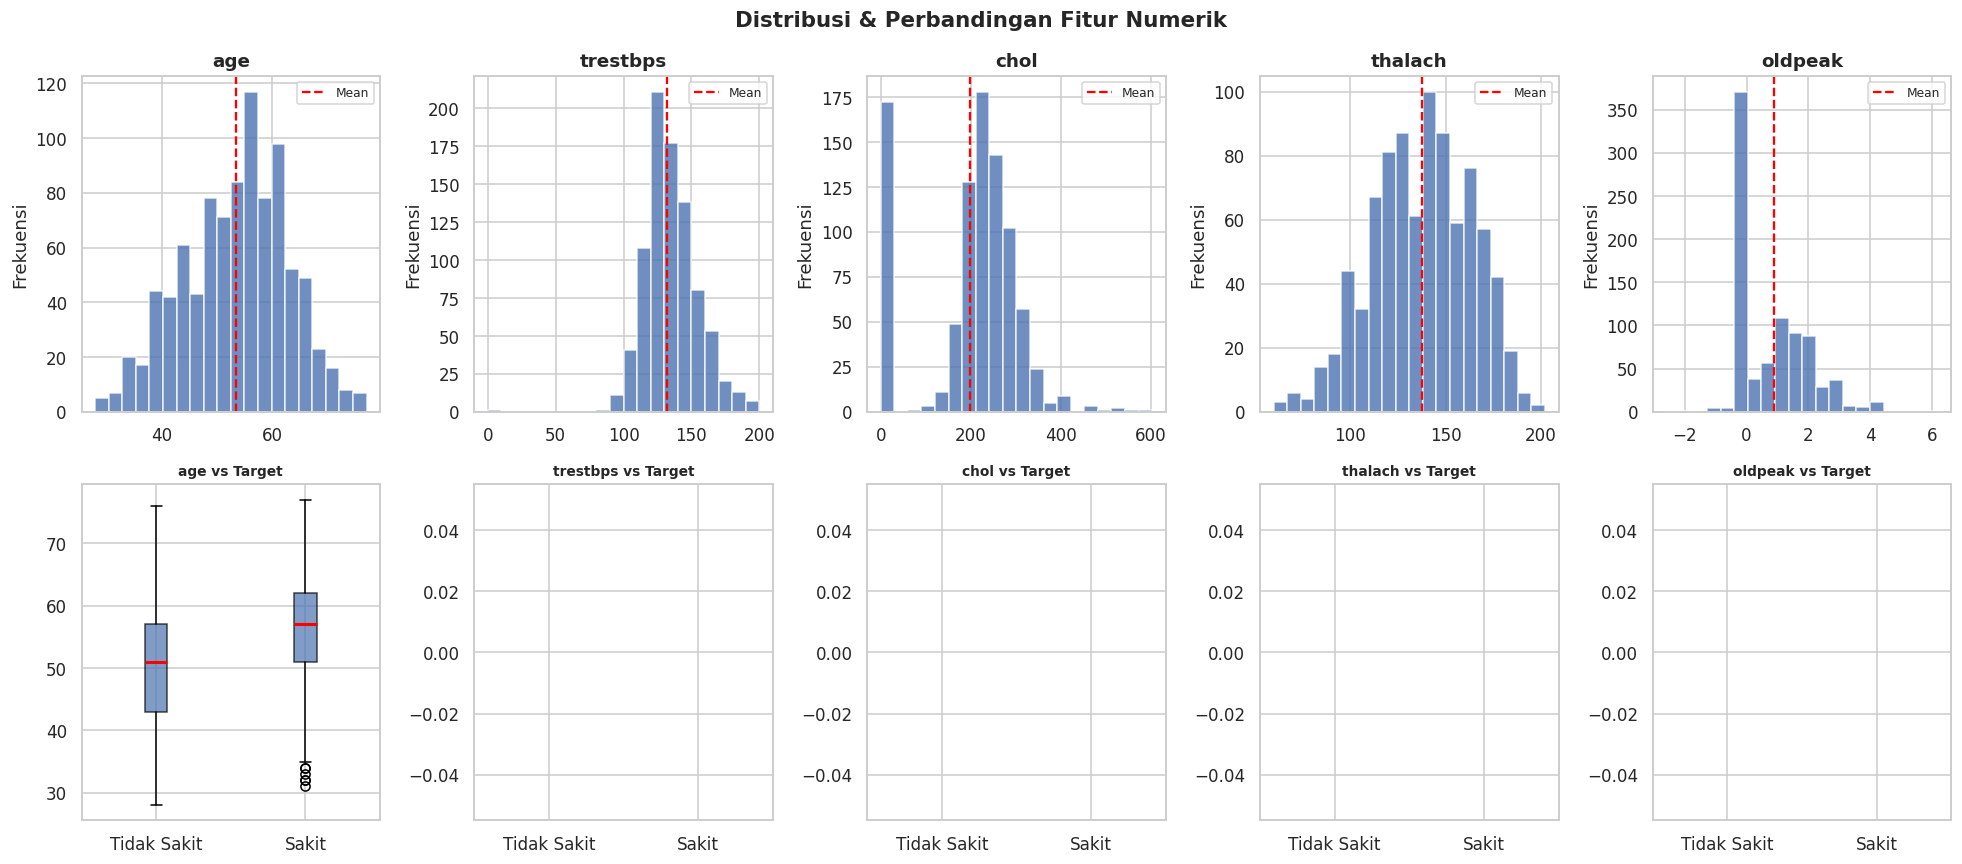

In [7]:
# ── 4.2 Distribusi Fitur Numerik ──────────────────────────────
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for i, col in enumerate(num_cols):
    # Histogram
    axes[0, i].hist(df[col], bins=20, color='#4C72B0', edgecolor='white', alpha=0.8)
    axes[0, i].set_title(col, fontweight='bold')
    axes[0, i].set_ylabel('Frekuensi')
    axes[0, i].axvline(df[col].mean(), color='red', linestyle='--', label='Mean')
    axes[0, i].legend(fontsize=8)

    # Boxplot berdasarkan target
    data_pos = df[df['condition'] == 1][col]
    data_neg = df[df['condition'] == 0][col]
    axes[1, i].boxplot([data_neg, data_pos], labels=['Tidak Sakit', 'Sakit'],
                       patch_artist=True,
                       boxprops=dict(facecolor='#4C72B0', alpha=0.7),
                       medianprops=dict(color='red', linewidth=2))
    axes[1, i].set_title(f'{col} vs Target', fontweight='bold', fontsize=9)

plt.suptitle('Distribusi & Perbandingan Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


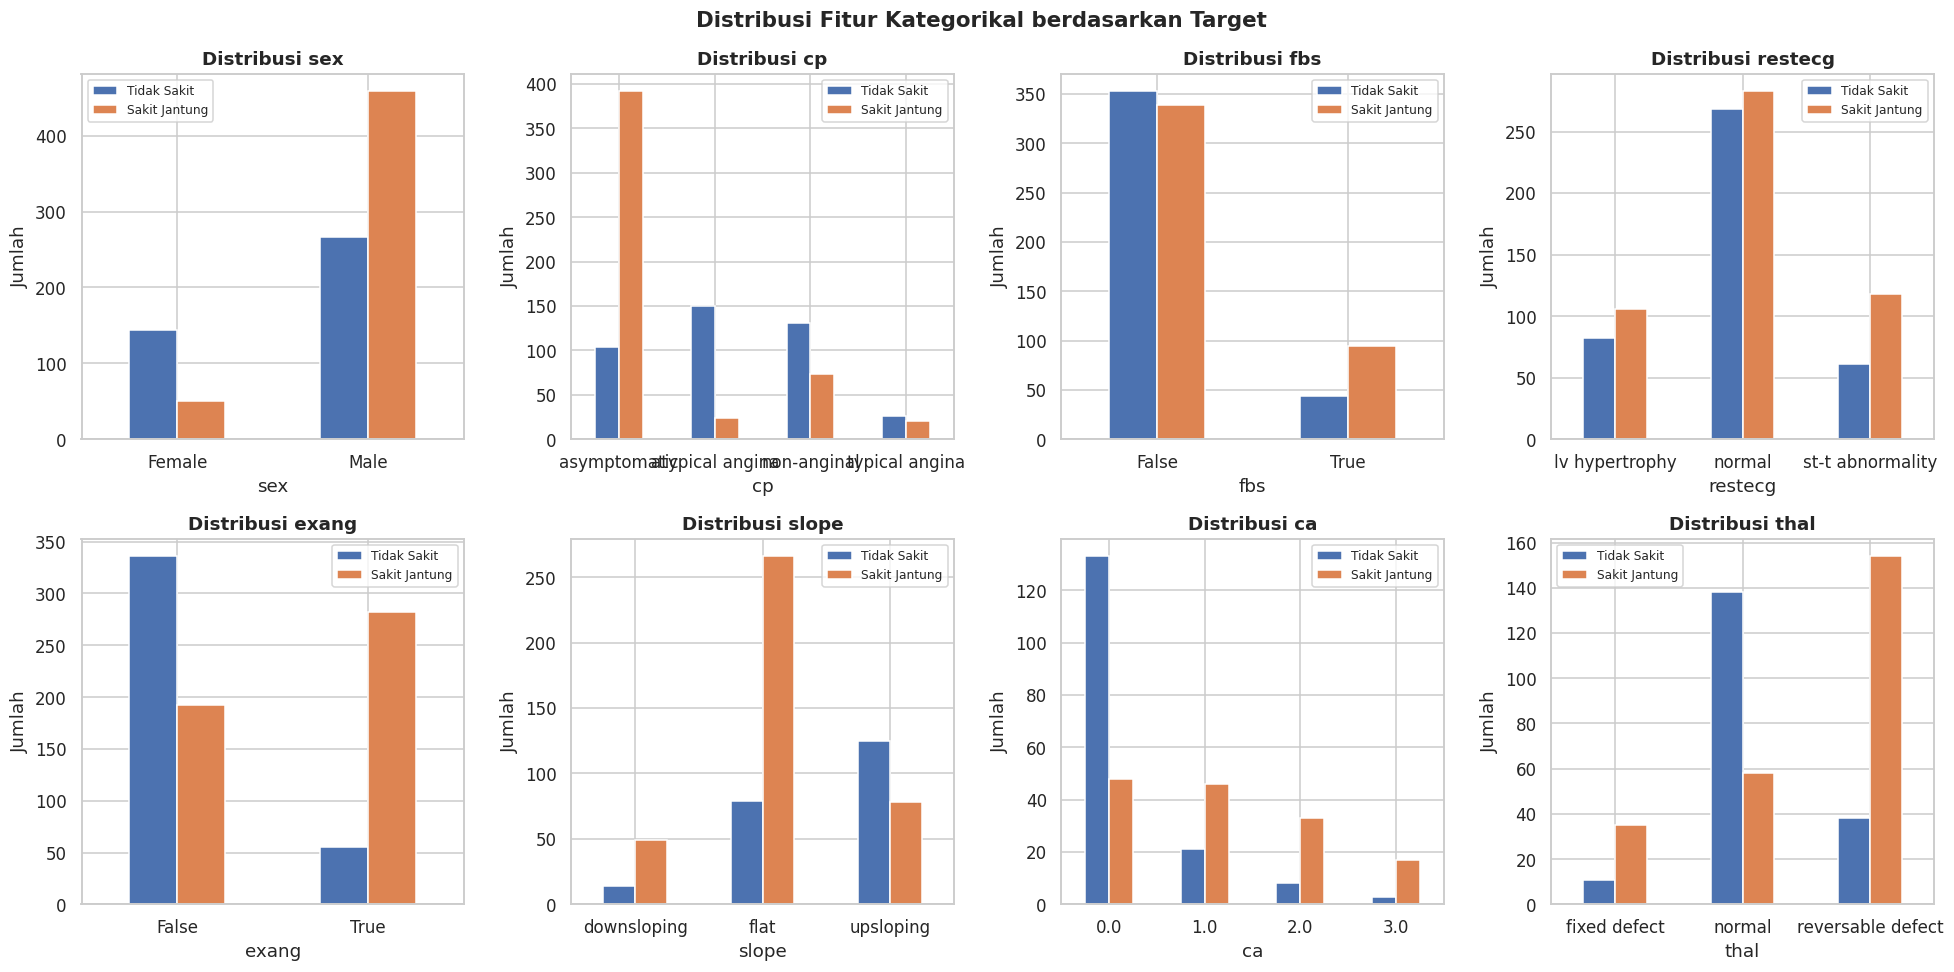

In [8]:
# ── 4.3 Distribusi Fitur Kategorikal ──────────────────────────
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
cat_labels = {
    'sex': {0: 'Wanita', 1: 'Pria'},
    'fbs': {0: '≤120', 1: '>120'},
    'exang': {0: 'Tidak', 1: 'Ya'}
}

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['condition'])
    ct.plot(kind='bar', ax=axes[i], color=['#4C72B0', '#DD8452'],
            edgecolor='white', rot=0)
    axes[i].set_title(f'Distribusi {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Jumlah')
    axes[i].legend(['Tidak Sakit', 'Sakit Jantung'], fontsize=8)

plt.suptitle('Distribusi Fitur Kategorikal berdasarkan Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [12]:
# ── 4.4 Heatmap Korelasi ──────────────────────────────────────
plt.figure(figsize=(13, 10))
corr_matrix = df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Heatmap Korelasi Antar Fitur', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Fitur paling berkorelasi dengan target
print("\n🔗 Korelasi Fitur terhadap Target (|corr| terbesar):")
corr_target = corr_matrix['condition'].drop('condition').abs().sort_values(ascending=False)
print(corr_target.round(3).to_string())


ValueError: could not convert string to float: 'Male'

<Figure size 1430x1100 with 0 Axes>

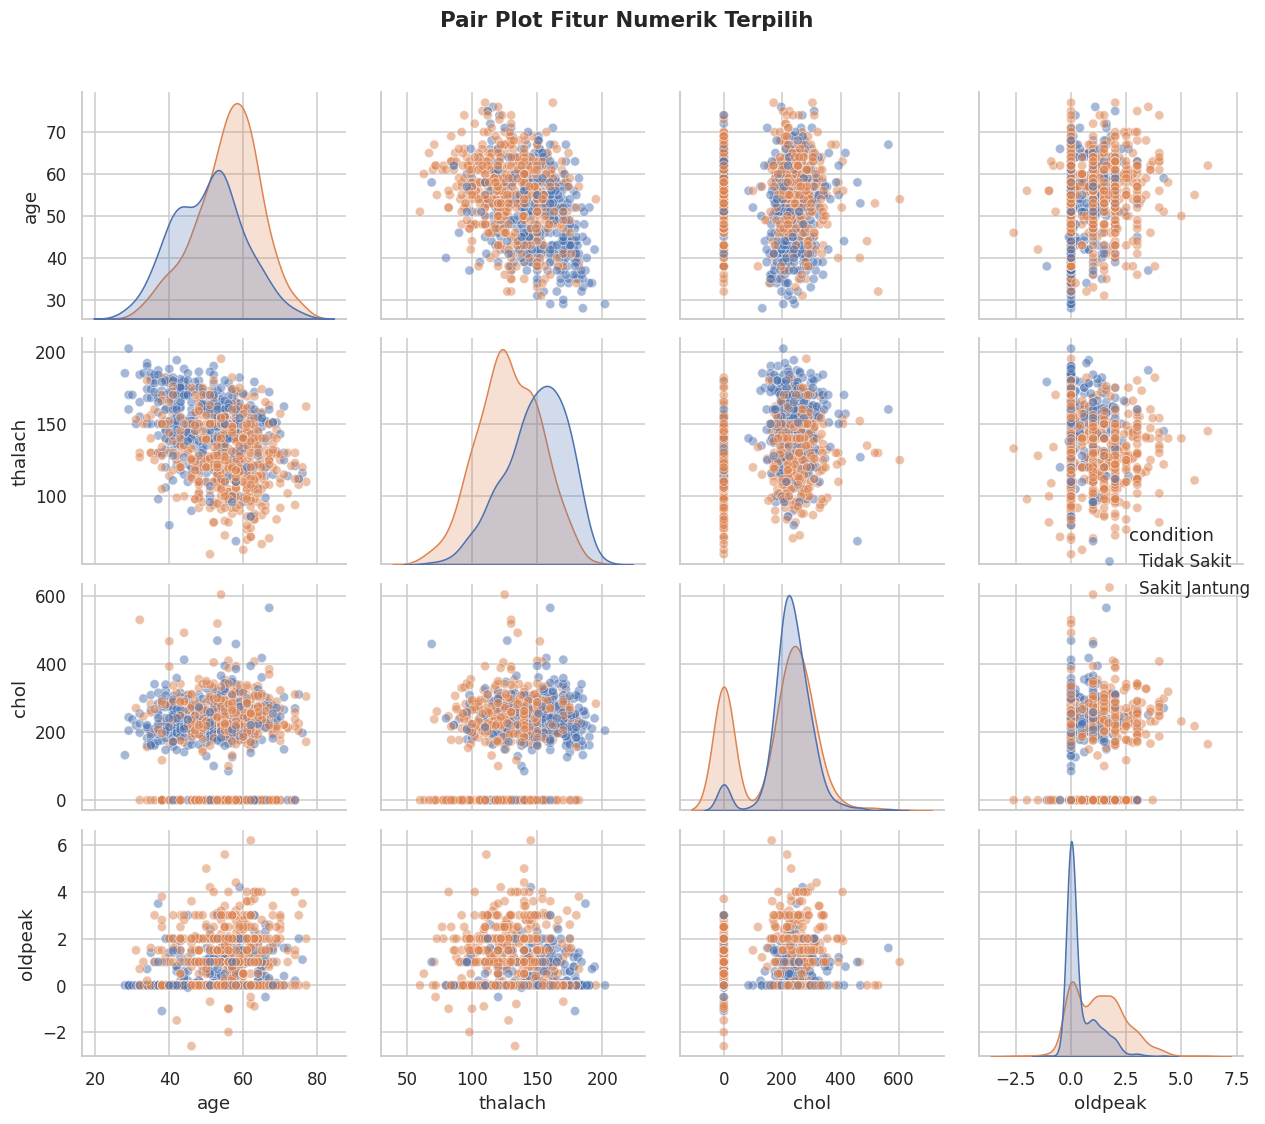

In [ ]:
# ── 4.5 Pair Plot Fitur Terpilih ──────────────────────────────
selected = ['age', 'thalach', 'chol', 'oldpeak', 'condition']
pair_df = df[selected].copy()
pair_df['condition'] = pair_df['condition'].map({0: 'Tidak Sakit', 1: 'Sakit Jantung'})

g = sns.pairplot(pair_df, hue='condition', palette=['#4C72B0', '#DD8452'],
                 diag_kind='kde', plot_kws={'alpha': 0.5})
g.figure.suptitle('Pair Plot Fitur Numerik Terpilih', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


🔍 Analisis Nilai Kosong:
          Jumlah Kosong  Persentase (%)
ca                  611           66.41
thal                486           52.83
slope               309           33.59
fbs                  90            9.78
oldpeak              62            6.74
trestbps             59            6.41
thalach              55            5.98
exang                55            5.98
chol                 30            3.26
restecg               2            0.22


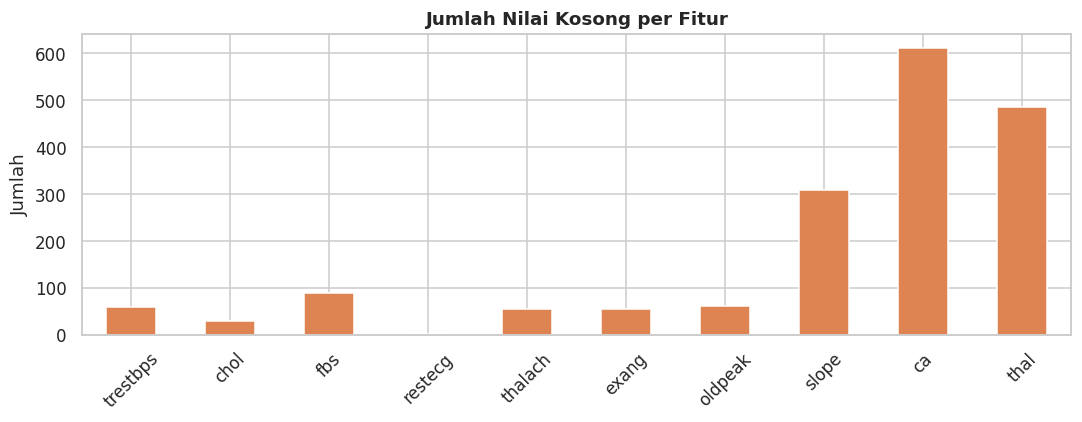

In [ ]:
# ── 4.6 Analisis Nilai Kosong ─────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Jumlah Kosong': missing,
    'Persentase (%)': missing_pct.round(2)
}).sort_values('Jumlah Kosong', ascending=False)

print("🔍 Analisis Nilai Kosong:")
print("=" * 40)
print(missing_df[missing_df['Jumlah Kosong'] > 0].to_string()
      if missing_df['Jumlah Kosong'].sum() > 0
      else "✅ Tidak ada nilai kosong dalam dataset")

# Visualisasi
if missing.sum() > 0:
    plt.figure(figsize=(10, 4))
    missing[missing > 0].plot(kind='bar', color='#DD8452', edgecolor='white')
    plt.title('Jumlah Nilai Kosong per Fitur', fontweight='bold')
    plt.ylabel('Jumlah')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# **5. Data Preprocessing**

Pada tahap ini, kita mempersiapkan data agar siap digunakan oleh model machine learning.
Langkah-langkah yang dilakukan:
1. Menangani Nilai Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Deteksi dan Penanganan Outlier
4. Encoding Fitur Kategorikal (jika diperlukan)
5. Normalisasi / Standarisasi Fitur
6. Pemisahan Fitur dan Target
7. Train-Test Split


In [ ]:
# ── 5.1 Menangani Nilai Kosong ────────────────────────────────
print("📌 Langkah 1: Menangani Nilai Kosong")
print("-" * 40)

missing_before = df.isnull().sum().sum()
print(f"Nilai kosong sebelum: {missing_before}")

# Imputasi median untuk fitur numerik (robust terhadap outlier)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols_feat = [c for c in num_cols if c != 'condition']

imputer = SimpleImputer(strategy='median')
df[num_cols_feat] = imputer.fit_transform(df[num_cols_feat])

missing_after = df.isnull().sum().sum()
print(f"Nilai kosong setelah : {missing_after}")
print("✅ Penanganan nilai kosong selesai")


📌 Langkah 1: Menangani Nilai Kosong
----------------------------------------
Nilai kosong sebelum: 1759
Nilai kosong setelah : 0
✅ Penanganan nilai kosong selesai


In [ ]:
# ── 5.2 Menghapus Data Duplikat ───────────────────────────────
print("📌 Langkah 2: Menghapus Data Duplikat")
print("-" * 40)

dup_before = df.duplicated().sum()
print(f"Duplikat sebelum: {dup_before}")

df = df.drop_duplicates().reset_index(drop=True)

dup_after = df.duplicated().sum()
print(f"Duplikat setelah : {dup_after}")
print(f"Dataset shape    : {df.shape}")
print("✅ Penanganan duplikat selesai")


📌 Langkah 2: Menghapus Data Duplikat
----------------------------------------
Duplikat sebelum: 2
Duplikat setelah : 0
Dataset shape    : (918, 14)
✅ Penanganan duplikat selesai


📌 Langkah 3: Deteksi dan Penanganan Outlier (Metode IQR)
--------------------------------------------------
  trestbps    : 28 outlier → di-cap ke [90.0, 170.0]
  chol        : 185 outlier → di-cap ke [42.6, 401.6]
  thalach     : 2 outlier → di-cap ke [66.4, 209.4]
  oldpeak     : 16 outlier → di-cap ke [-2.2, 3.8]


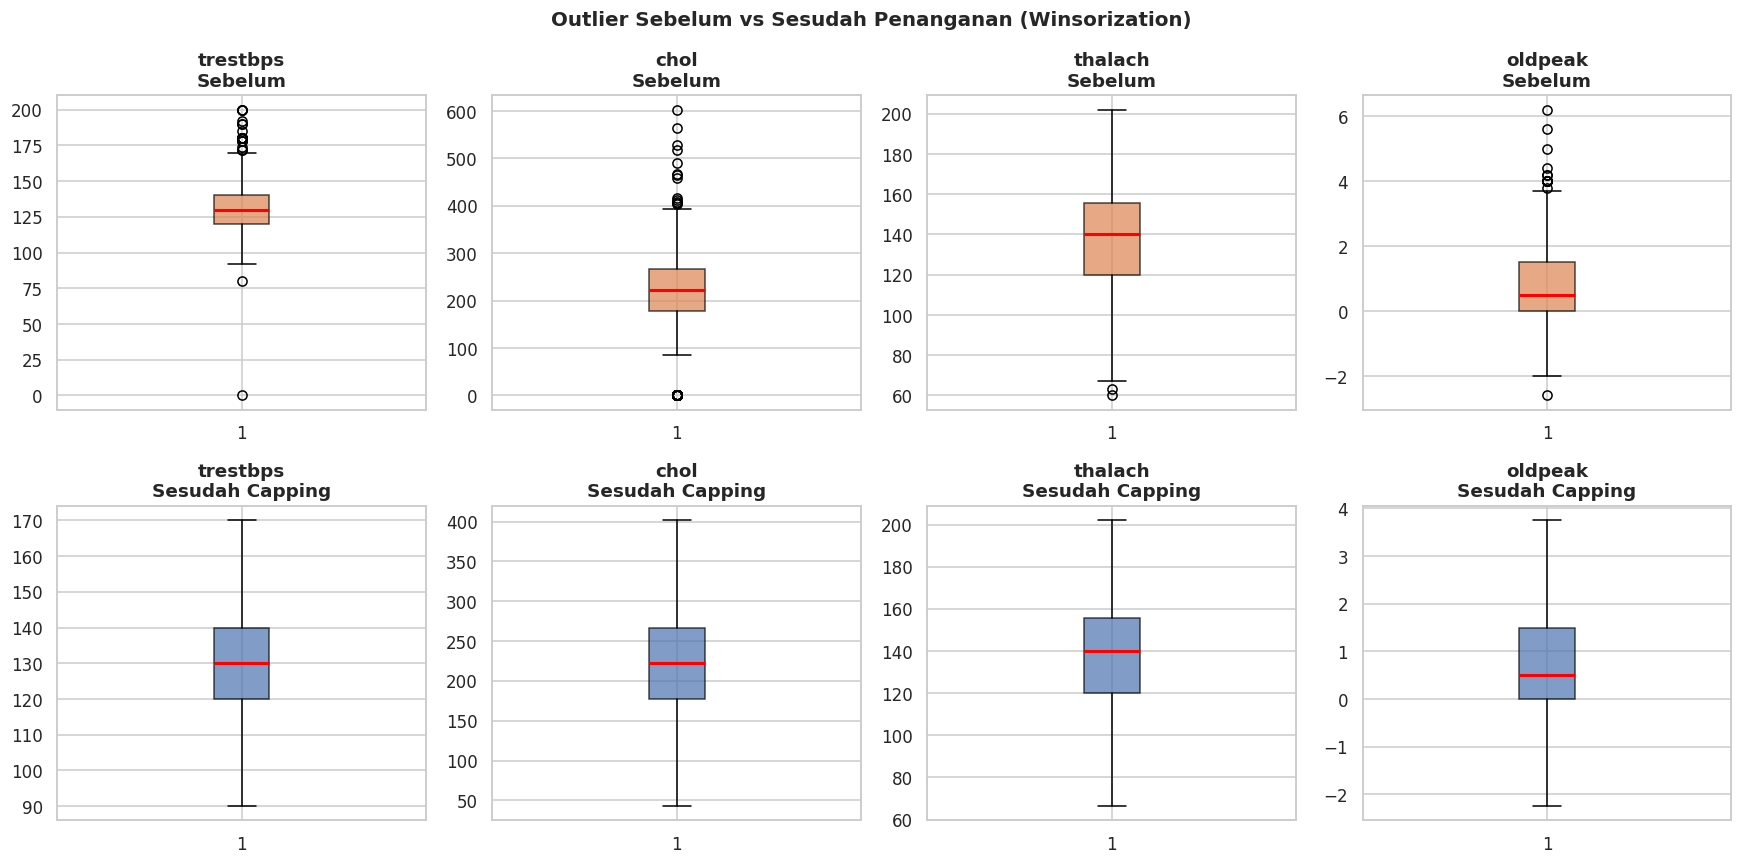


✅ Penanganan outlier selesai


In [ ]:
# ── 5.3 Deteksi dan Penanganan Outlier (IQR Method) ──────────
print("📌 Langkah 3: Deteksi dan Penanganan Outlier (Metode IQR)")
print("-" * 50)

outlier_cols = ['trestbps', 'chol', 'thalach', 'oldpeak']
df_clean = df.copy()

fig, axes = plt.subplots(2, len(outlier_cols), figsize=(16, 8))

for i, col in enumerate(outlier_cols):
    Q1  = df_clean[col].quantile(0.25)
    Q3  = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outlier = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()

    # Capping (Winsorization) — lebih aman daripada drop untuk dataset kecil
    df_clean[col] = df_clean[col].clip(lower, upper)

    # Plot sebelum (menggunakan df asli)
    axes[0, i].boxplot(df[col], patch_artist=True,
                       boxprops=dict(facecolor='#DD8452', alpha=0.7),
                       medianprops=dict(color='red', linewidth=2))
    axes[0, i].set_title(f'{col}\nSebelum', fontweight='bold')

    # Plot sesudah
    axes[1, i].boxplot(df_clean[col], patch_artist=True,
                       boxprops=dict(facecolor='#4C72B0', alpha=0.7),
                       medianprops=dict(color='red', linewidth=2))
    axes[1, i].set_title(f'{col}\nSesudah Capping', fontweight='bold')

    print(f"  {col:<12}: {n_outlier} outlier → di-cap ke [{lower:.1f}, {upper:.1f}]")

df = df_clean.copy()
plt.suptitle('Outlier Sebelum vs Sesudah Penanganan (Winsorization)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("\n✅ Penanganan outlier selesai")


In [ ]:
# ── 5.4 Pemisahan Fitur dan Target ────────────────────────────
print("📌 Langkah 4: Pemisahan Fitur dan Target")
print("-" * 40)

X = df.drop('condition', axis=1)
y = df['condition']

print(f"Bentuk X (fitur) : {X.shape}")
print(f"Bentuk y (target): {y.shape}")
print(f"\nFitur yang digunakan ({len(X.columns)}):")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2}. {col}")


📌 Langkah 4: Pemisahan Fitur dan Target
----------------------------------------
Bentuk X (fitur) : (918, 13)
Bentuk y (target): (918,)

Fitur yang digunakan (13):
   1. age
   2. sex
   3. cp
   4. trestbps
   5. chol
   6. fbs
   7. restecg
   8. thalach
   9. exang
  10. oldpeak
  11. slope
  12. ca
  13. thal


In [ ]:
# ── 5.5 Train-Test Split ──────────────────────────────────────
print("📌 Langkah 5: Pembagian Data Latih dan Uji")
print("-" * 40)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # jaga proporsi kelas
)

print(f"Data Latih  : {X_train.shape[0]} sampel ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Data Uji    : {X_test.shape[0]} sampel ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nDistribusi target pada data latih:")
print(y_train.value_counts().to_string())
print(f"\nDistribusi target pada data uji:")
print(y_test.value_counts().to_string())


📌 Langkah 5: Pembagian Data Latih dan Uji
----------------------------------------
Data Latih  : 734 sampel (80%)
Data Uji    : 184 sampel (20%)

Distribusi target pada data latih:
condition
1    406
0    328

Distribusi target pada data uji:
condition
1    102
0     82


In [ ]:
# ── 5.6 Standarisasi Fitur Numerik ────────────────────────────
print("📌 Langkah 6: Standarisasi Fitur Numerik (StandardScaler)")
print("-" * 50)

# Hanya skala fitur numerik yang memiliki rentang besar
scale_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols]  = scaler.transform(X_test[scale_cols])

print("Statistik setelah standarisasi (data latih):")
print(X_train_scaled[scale_cols].describe().round(3).to_string())
print("\n✅ Standarisasi selesai")


📌 Langkah 6: Standarisasi Fitur Numerik (StandardScaler)
--------------------------------------------------
Statistik setelah standarisasi (data latih):
         age  trestbps   chol  thalach  oldpeak
count 734.00    734.00 734.00   734.00   734.00
mean   -0.00     -0.00   0.00    -0.00    -0.00
std     1.00      1.00   1.00     1.00     1.00
min    -2.74     -2.49  -1.78    -2.84    -3.03
25%    -0.70     -0.70  -0.33    -0.71    -0.83
50%     0.05     -0.10   0.17     0.09    -0.34
75%     0.69      0.49   0.65     0.68     0.64
max     2.51      2.28   2.10     2.55     2.84

✅ Standarisasi selesai


In [ ]:
# ── 5.7 Ringkasan Preprocessing ───────────────────────────────
print("=" * 60)
print("📋 RINGKASAN PREPROCESSING")
print("=" * 60)
print(f"  Dataset awal          : {303} baris × 14 kolom")
print(f"  Dataset final         : {df.shape[0]} baris × {df.shape[1]} kolom")
print(f"  Fitur input           : {X_train_scaled.shape[1]}")
print(f"  Data latih            : {X_train_scaled.shape[0]} sampel")
print(f"  Data uji              : {X_test_scaled.shape[0]} sampel")
print(f"  Penanganan missing    : Imputasi Median")
print(f"  Penanganan duplikat   : Drop duplicates")
print(f"  Penanganan outlier    : Winsorization (IQR)")
print(f"  Standarisasi          : StandardScaler")
print("=" * 60)
print("\n✅ Data siap digunakan untuk pelatihan model!")

# Simpan data hasil preprocessing ke CSV (siap untuk automate_*.py)
X_train_out = X_train_scaled.copy()
X_train_out['condition'] = y_train.values
X_train_out.to_csv('heart_disease_preprocessing_train.csv', index=False)

X_test_out = X_test_scaled.copy()
X_test_out['condition'] = y_test.values
X_test_out.to_csv('heart_disease_preprocessing_test.csv', index=False)

print("\n💾 Dataset hasil preprocessing disimpan:")
print("   → heart_disease_preprocessing_train.csv")
print("   → heart_disease_preprocessing_test.csv")


📋 RINGKASAN PREPROCESSING
  Dataset awal          : 303 baris × 14 kolom
  Dataset final         : 918 baris × 14 kolom
  Fitur input           : 13
  Data latih            : 734 sampel
  Data uji              : 184 sampel
  Penanganan missing    : Imputasi Median
  Penanganan duplikat   : Drop duplicates
  Penanganan outlier    : Winsorization (IQR)
  Standarisasi          : StandardScaler

✅ Data siap digunakan untuk pelatihan model!

💾 Dataset hasil preprocessing disimpan:
   → heart_disease_preprocessing_train.csv
   → heart_disease_preprocessing_test.csv


# **6. Automate Preprocessing (Skilled)**

Pada tahap ini, kita membuat dan menjalankan script `automate_Andi_Rafli.py` yang mengotomatisasi seluruh pipeline preprocessing — dari loading data mentah hingga menghasilkan file CSV siap latih.


In [ ]:
%%writefile automate_Andi_Rafli.py
"""
automate_Andi_Rafli.py
══════════════════════════════════════════════════════════════
Script otomatisasi preprocessing dataset Heart Disease UCI.

Penggunaan:
    python automate_Andi_Rafli.py --input heart_disease_uci.csv
    python automate_Andi_Rafli.py --input heart_disease_uci.csv --output_dir hasil_preprocessing

Output:
    <output_dir>/heart_disease_preprocessing_train.csv
    <output_dir>/heart_disease_preprocessing_test.csv
══════════════════════════════════════════════════════════════
"""

import argparse
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

TARGET_COL   = "condition"
SCALE_COLS   = ["age", "trestbps", "chol", "thalach", "oldpeak"]
OUTLIER_COLS = ["trestbps", "chol", "thalach", "oldpeak"]
TEST_SIZE    = 0.2
RANDOM_STATE = 42


def load_data(filepath: str) -> pd.DataFrame:
    df = pd.read_csv(filepath)
    # Drop kolom tidak relevan jika ada
    drop_cols = ["id", "dataset"]
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])
    # Rename kolom ke standar
    df = df.rename(columns={"thalch": "thalach", "num": "condition"})
    # Binarisasi target
    df["condition"] = (df["condition"] > 0).astype(int)
    # Encode kolom kategorikal string
    if df["sex"].dtype == object:
        df["sex"] = df["sex"].map({"Male": 1, "Female": 0})
    cp_map = {"typical angina": 0, "atypical angina": 1, "non-anginal": 2, "asymptomatic": 3}
    if df["cp"].dtype == object:
        df["cp"] = df["cp"].map(cp_map)
    for col in ["fbs", "exang"]:
        if df[col].dtype == object:
            df[col] = df[col].map({True: 1, False: 0, "True": 1, "False": 0}).astype(float)
    if df["restecg"].dtype == object:
        df["restecg"] = df["restecg"].str.lower().map({"normal": 0, "st-t abnormality": 1, "lv hypertrophy": 2})
    if df["slope"].dtype == object:
        df["slope"] = df["slope"].str.lower().map({"upsloping": 0, "flat": 1, "downsloping": 2})
    if df["thal"].dtype == object:
        df["thal"] = df["thal"].str.lower().map({"normal": 1, "fixed defect": 2, "reversable defect": 3})
    print(f"[load]  {df.shape[0]} baris × {df.shape[1]} kolom")
    return df


def handle_missing(df: pd.DataFrame) -> pd.DataFrame:
    feat_cols = [c for c in df.columns if c != TARGET_COL]
    imputer = SimpleImputer(strategy="median")
    df[feat_cols] = imputer.fit_transform(df[feat_cols])
    print(f"[missing]  nilai kosong tersisa: {df.isnull().sum().sum()}")
    return df


def remove_duplicates(df: pd.DataFrame) -> pd.DataFrame:
    before = len(df)
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"[duplicates]  dihapus: {before - len(df)} | tersisa: {len(df)}")
    return df


def handle_outliers(df: pd.DataFrame) -> pd.DataFrame:
    for col in OUTLIER_COLS:
        if col not in df.columns:
            continue
        Q1, Q3 = df[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        n_out = ((df[col] < lo) | (df[col] > hi)).sum()
        df[col] = df[col].clip(lo, hi)
        print(f"[outlier]  {col}: {n_out} outlier di-cap ke [{lo:.1f}, {hi:.1f}]")
    return df


def split_and_scale(df: pd.DataFrame):
    X = df.drop(TARGET_COL, axis=1)
    y = df[TARGET_COL]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )
    scaler = StandardScaler()
    X_train = X_train.copy()
    X_test  = X_test.copy()
    cols = [c for c in SCALE_COLS if c in X_train.columns]
    X_train[cols] = scaler.fit_transform(X_train[cols])
    X_test[cols]  = scaler.transform(X_test[cols])
    print(f"[split]  train: {X_train.shape[0]} | test: {X_test.shape[0]}")
    return X_train, X_test, y_train, y_test


def save_results(X_train, y_train, X_test, y_test, output_dir: str):
    os.makedirs(output_dir, exist_ok=True)
    train_path = os.path.join(output_dir, "heart_disease_preprocessing_train.csv")
    test_path  = os.path.join(output_dir, "heart_disease_preprocessing_test.csv")
    train_df = X_train.copy(); train_df[TARGET_COL] = y_train.values
    test_df  = X_test.copy();  test_df[TARGET_COL]  = y_test.values
    train_df.to_csv(train_path, index=False)
    test_df.to_csv(test_path,  index=False)
    print(f"[save]  train → {train_path}")
    print(f"[save]  test  → {test_path}")


def main():
    parser = argparse.ArgumentParser(description="Automate preprocessing Heart Disease UCI")
    parser.add_argument("--input",      required=True, help="Path ke file CSV raw")
    parser.add_argument("--output_dir", default="heart_disease_preprocessing",
                        help="Folder output (default: heart_disease_preprocessing)")
    args = parser.parse_args()

    print("=" * 60)
    print("  AUTOMATE PREPROCESSING — Andi Rafli")
    print("=" * 60)
    df = load_data(args.input)
    df = handle_missing(df)
    df = remove_duplicates(df)
    df = handle_outliers(df)
    X_train, X_test, y_train, y_test = split_and_scale(df)
    save_results(X_train, y_train, X_test, y_test, args.output_dir)
    print("\n✅ Preprocessing selesai!")
    print("=" * 60)


if __name__ == "__main__":
    main()


Writing automate_Andi_Rafli.py


In [ ]:
!python automate_Andi_Rafli.py --input heart_disease_uci.csv --output_dir heart_disease_preprocessing

  AUTOMATE PREPROCESSING — Andi Rafli
[load]  920 baris × 14 kolom
[missing]  nilai kosong tersisa: 0
[duplicates]  dihapus: 2 | tersisa: 918
[outlier]  trestbps: 28 outlier di-cap ke [90.0, 170.0]
[outlier]  chol: 185 outlier di-cap ke [42.6, 401.6]
[outlier]  thalach: 2 outlier di-cap ke [66.4, 209.4]
[outlier]  oldpeak: 16 outlier di-cap ke [-2.2, 3.8]
[split]  train: 734 | test: 184
[save]  train → heart_disease_preprocessing/heart_disease_preprocessing_train.csv
[save]  test  → heart_disease_preprocessing/heart_disease_preprocessing_test.csv

✅ Preprocessing selesai!


# **7. Membangun Model dengan MLflow (Kriteria 2)**

Pada tahap ini, kita melatih model machine learning dan merekam eksperimen menggunakan **MLflow Tracking**. Tersedia dua script:
- `modelling.py` — Basic: menggunakan MLflow autolog
- `modelling_tuning.py` — Skilled: manual logging + GridSearchCV hyperparameter tuning


In [ ]:
!pip install mlflow==2.19.0 -q
print('✅ MLflow installed')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.4/27.4 MB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 129.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 907.5/907.5 kB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.9/214.9 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 6.4 MB/s eta 0:00:00
✅ MLflow installed


In [ ]:
import mlflow
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec
import pandas as pd
import numpy as np
import os, time

mlflow.set_tracking_uri("http://127.0.0.1:5000")
client = mlflow.tracking.MlflowClient()
print("✅ MLflow client siap")

✅ MLflow client siap


In [ ]:
%%writefile modelling.py
"""
modelling.py
============
Pelatihan model Machine Learning menggunakan MLflow Tracking UI.
Menggunakan autolog dari MLflow (Kriteria 2 Basic).

Penggunaan:
    mlflow ui                          # jalankan di terminal lain
    python modelling.py                # jalankan pelatihan

Pastikan MLflow sudah terinstall:
    pip install mlflow scikit-learn pandas numpy
"""

import os
import numpy as np
import pandas as pd
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, confusion_matrix,
    classification_report
)


# ──────────────────────────────────────────────────────────────
# KONFIGURASI
# ──────────────────────────────────────────────────────────────
TRAIN_PATH = os.path.join('heart_disease_preprocessing',
                          'heart_disease_preprocessing_train.csv')
TEST_PATH  = os.path.join('heart_disease_preprocessing',
                          'heart_disease_preprocessing_test.csv')

EXPERIMENT_NAME = "Heart_Disease_Modelling"
RANDOM_STATE    = 42


# ──────────────────────────────────────────────────────────────
# LOAD DATA
# ──────────────────────────────────────────────────────────────
def load_data():
    """Memuat dataset hasil preprocessing."""
    if not os.path.exists(TRAIN_PATH) or not os.path.exists(TEST_PATH):
        raise FileNotFoundError(
            f"❌ File preprocessing tidak ditemukan!\n"
            f"   Jalankan automate_Andi_Rafli.py terlebih dahulu."
        )

    train_df = pd.read_csv(TRAIN_PATH)
    test_df  = pd.read_csv(TEST_PATH)

    X_train = train_df.drop('condition', axis=1)
    y_train = train_df['condition']
    X_test  = test_df.drop('condition', axis=1)
    y_test  = test_df['condition']

    print(f"✅ Data latih : {X_train.shape}")
    print(f"✅ Data uji   : {X_test.shape}")
    return X_train, X_test, y_train, y_test


# ──────────────────────────────────────────────────────────────
# TRAINING DENGAN AUTOLOG
# ──────────────────────────────────────────────────────────────
def train_model(model, model_name, X_train, X_test, y_train, y_test):
    """Melatih satu model dengan MLflow autolog."""

    # Aktifkan autolog
    mlflow.sklearn.autolog()

    with mlflow.start_run(run_name=model_name):

        # Training
        model.fit(X_train, y_train)

        # Prediksi
        y_pred      = model.predict(X_test)
        y_pred_prob = model.predict_proba(X_test)[:, 1] \
                      if hasattr(model, 'predict_proba') else None

        # Tambahan metrik manual (autolog sudah cover, ini sebagai pelengkap)
        acc       = accuracy_score(y_test, y_pred)
        f1        = f1_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall    = recall_score(y_test, y_pred)
        auc       = roc_auc_score(y_test, y_pred_prob) \
                    if y_pred_prob is not None else 0.0

        mlflow.log_metric("test_accuracy",  acc)
        mlflow.log_metric("test_f1_score",  f1)
        mlflow.log_metric("test_precision", precision)
        mlflow.log_metric("test_recall",    recall)
        mlflow.log_metric("test_roc_auc",   auc)

        # Tag
        mlflow.set_tag("model_name",  model_name)
        mlflow.set_tag("dataset",     "Heart Disease UCI")
        mlflow.set_tag("author",      "Andi Rafli")

        print(f"\n{'='*50}")
        print(f"  Model   : {model_name}")
        print(f"  Accuracy: {acc:.4f}")
        print(f"  F1 Score: {f1:.4f}")
        print(f"  ROC AUC : {auc:.4f}")
        print(f"{'='*50}")
        print(classification_report(y_test, y_pred,
              target_names=['Tidak Sakit', 'Sakit Jantung']))

        return acc, f1, auc


# ──────────────────────────────────────────────────────────────
# MAIN
# ──────────────────────────────────────────────────────────────
def main():
    print("=" * 60)
    print("  MODELLING — Heart Disease UCI (MLflow Autolog)")
    print("=" * 60)

    # Setup MLflow
    mlflow.set_tracking_uri("http://127.0.0.1:5000")
    mlflow.set_experiment(EXPERIMENT_NAME)

    # Load data
    X_train, X_test, y_train, y_test = load_data()

    # Definisi model
    models = {
        "RandomForest": RandomForestClassifier(
            n_estimators=100,
            random_state=RANDOM_STATE
        ),
        "LogisticRegression": LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        ),
    }

    # Latih semua model
    results = {}
    for name, model in models.items():
        print(f"\n🔄 Melatih {name}...")
        acc, f1, auc = train_model(
            model, name, X_train, X_test, y_train, y_test
        )
        results[name] = {'accuracy': acc, 'f1': f1, 'auc': auc}

    # Ringkasan
    print("\n" + "=" * 60)
    print("  RINGKASAN HASIL")
    print("=" * 60)
    results_df = pd.DataFrame(results).T.round(4)
    print(results_df.to_string())

    best_model = max(results, key=lambda k: results[k]['accuracy'])
    print(f"\n🏆 Model terbaik: {best_model} "
          f"(accuracy={results[best_model]['accuracy']:.4f})")
    print("\n✅ Selesai! Buka MLflow UI: http://127.0.0.1:5000")


if __name__ == '__main__':
    main()


Overwriting modelling.py


In [ ]:
%%writefile modelling_tuning.py
"""
modelling_tuning.py
===================
Pelatihan model dengan Hyperparameter Tuning menggunakan MLflow.
Menggunakan MANUAL LOGGING (bukan autolog) — Kriteria 2 Skilled.

Penggunaan:
    mlflow ui                          # jalankan di terminal lain
    python modelling_tuning.py         # jalankan pelatihan + tuning

Pastikan MLflow sudah terinstall:
    pip install mlflow scikit-learn pandas numpy
"""

import os
import json
import numpy as np
import pandas as pd
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)
import matplotlib
matplotlib.use('Agg')   # non-interactive backend
import matplotlib.pyplot as plt


# ──────────────────────────────────────────────────────────────
# KONFIGURASI
# ──────────────────────────────────────────────────────────────
TRAIN_PATH = os.path.join('heart_disease_preprocessing',
                          'heart_disease_preprocessing_train.csv')
TEST_PATH  = os.path.join('heart_disease_preprocessing',
                          'heart_disease_preprocessing_test.csv')

EXPERIMENT_NAME = "Heart_Disease_Tuning"
RANDOM_STATE    = 42
CV_FOLDS        = 5


# ──────────────────────────────────────────────────────────────
# LOAD DATA
# ──────────────────────────────────────────────────────────────
def load_data():
    """Memuat dataset hasil preprocessing."""
    if not os.path.exists(TRAIN_PATH) or not os.path.exists(TEST_PATH):
        raise FileNotFoundError(
            "❌ File preprocessing tidak ditemukan!\n"
            "   Jalankan automate_Andi_Rafli.py terlebih dahulu."
        )

    train_df = pd.read_csv(TRAIN_PATH)
    test_df  = pd.read_csv(TEST_PATH)

    X_train = train_df.drop('condition', axis=1)
    y_train = train_df['condition']
    X_test  = test_df.drop('condition', axis=1)
    y_test  = test_df['condition']

    print(f"✅ Data latih : {X_train.shape}")
    print(f"✅ Data uji   : {X_test.shape}")
    return X_train, X_test, y_train, y_test


# ──────────────────────────────────────────────────────────────
# ARTEFAK: CONFUSION MATRIX PLOT
# ──────────────────────────────────────────────────────────────
def plot_confusion_matrix(y_true, y_pred, model_name: str, save_path: str):
    """Membuat dan menyimpan plot confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.colorbar(im, ax=ax)

    classes = ['Tidak Sakit', 'Sakit Jantung']
    tick_marks = np.arange(len(classes))
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(classes, rotation=45, ha='right')
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(classes)

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha='center', va='center',
                    color='white' if cm[i, j] > thresh else 'black',
                    fontsize=14, fontweight='bold')

    ax.set_ylabel('Label Sebenarnya', fontsize=12)
    ax.set_xlabel('Label Prediksi', fontsize=12)
    ax.set_title(f'Confusion Matrix — {model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.close()
    print(f"   💾 Confusion matrix disimpan: {save_path}")


# ──────────────────────────────────────────────────────────────
# ARTEFAK: ROC CURVE PLOT
# ──────────────────────────────────────────────────────────────
def plot_roc_curve(y_true, y_prob, model_name: str, auc: float, save_path: str):
    """Membuat dan menyimpan plot ROC curve."""
    fpr, tpr, _ = roc_curve(y_true, y_prob)

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, color='#3B82F6', lw=2,
            label=f'ROC Curve (AUC = {auc:.4f})')
    ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Random')
    ax.fill_between(fpr, tpr, alpha=0.08, color='#3B82F6')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(f'ROC Curve — {model_name}', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=11)
    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.close()
    print(f"   💾 ROC curve disimpan: {save_path}")


# ──────────────────────────────────────────────────────────────
# ARTEFAK: FEATURE IMPORTANCE PLOT
# ──────────────────────────────────────────────────────────────
def plot_feature_importance(model, feature_names, model_name: str, save_path: str):
    """Membuat dan menyimpan plot feature importance."""
    if not hasattr(model, 'feature_importances_'):
        return

    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]

    fig, ax = plt.subplots(figsize=(8, 5))
    colors = ['#3B82F6' if i == 0 else '#93C5FD' for i in range(len(importances))]
    ax.bar(range(len(importances)),
           importances[indices],
           color=[colors[i] for i in range(len(importances))],
           edgecolor='white')
    ax.set_xticks(range(len(importances)))
    ax.set_xticklabels([feature_names[i] for i in indices],
                       rotation=45, ha='right', fontsize=10)
    ax.set_ylabel('Importance Score', fontsize=12)
    ax.set_title(f'Feature Importance — {model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.close()
    print(f"   💾 Feature importance disimpan: {save_path}")


# ──────────────────────────────────────────────────────────────
# TRAINING DENGAN MANUAL LOGGING + HYPERPARAMETER TUNING
# ──────────────────────────────────────────────────────────────
def train_with_tuning(model_class, param_grid, model_name,
                      X_train, X_test, y_train, y_test):
    """
    Melatih model dengan GridSearchCV + manual MLflow logging.
    Menyimpan artefak: confusion matrix, ROC curve, feature importance,
    classification report, dan best params JSON.
    """
    os.makedirs('artifacts', exist_ok=True)

    print(f"\n🔄 Hyperparameter tuning: {model_name}...")

    # GridSearch
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    grid_search = GridSearchCV(
        estimator=model_class(random_state=RANDOM_STATE),
        param_grid=param_grid,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1,
        verbose=0
    )
    grid_search.fit(X_train, y_train)

    best_model  = grid_search.best_estimator_
    best_params = grid_search.best_params_
    best_cv_acc = grid_search.best_score_

    # Prediksi
    y_pred      = best_model.predict(X_test)
    y_pred_prob = best_model.predict_proba(X_test)[:, 1]

    # Metrik
    acc       = accuracy_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    auc       = roc_auc_score(y_test, y_pred_prob)

    with mlflow.start_run(run_name=f"{model_name}_tuned"):

        # ── Manual Logging: Parameter ──────────────────────────
        mlflow.log_param("model_name",       model_name)
        mlflow.log_param("cv_folds",         CV_FOLDS)
        mlflow.log_param("random_state",     RANDOM_STATE)
        for k, v in best_params.items():
            mlflow.log_param(f"best_{k}", v)

        # ── Manual Logging: Metrik ─────────────────────────────
        mlflow.log_metric("cv_accuracy",     best_cv_acc)
        mlflow.log_metric("test_accuracy",   acc)
        mlflow.log_metric("test_f1_score",   f1)
        mlflow.log_metric("test_precision",  precision)
        mlflow.log_metric("test_recall",     recall)
        mlflow.log_metric("test_roc_auc",    auc)

        # ── Manual Logging: Tag ────────────────────────────────
        mlflow.set_tag("model_type",   model_name)
        mlflow.set_tag("tuning",       "GridSearchCV")
        mlflow.set_tag("dataset",      "Heart Disease UCI")
        mlflow.set_tag("author",       "Andi Rafli")

        # ── Artefak 1: Confusion Matrix ────────────────────────
        cm_path = f"artifacts/confusion_matrix_{model_name}.png"
        plot_confusion_matrix(y_test, y_pred, model_name, cm_path)
        mlflow.log_artifact(cm_path)

        # ── Artefak 2: ROC Curve ───────────────────────────────
        roc_path = f"artifacts/roc_curve_{model_name}.png"
        plot_roc_curve(y_test, y_pred_prob, model_name, auc, roc_path)
        mlflow.log_artifact(roc_path)

        # ── Artefak 3: Feature Importance ─────────────────────
        fi_path = f"artifacts/feature_importance_{model_name}.png"
        plot_feature_importance(best_model, X_train.columns.tolist(),
                                model_name, fi_path)
        if os.path.exists(fi_path):
            mlflow.log_artifact(fi_path)

        # ── Artefak 4: Classification Report ──────────────────
        report = classification_report(
            y_test, y_pred,
            target_names=['Tidak Sakit', 'Sakit Jantung']
        )
        report_path = f"artifacts/classification_report_{model_name}.txt"
        with open(report_path, 'w') as f:
            f.write(f"Model: {model_name}\n")
            f.write(f"Best Params: {best_params}\n\n")
            f.write(report)
        mlflow.log_artifact(report_path)
        print(f"   💾 Classification report disimpan: {report_path}")

        # ── Artefak 5: Best Params JSON ────────────────────────
        params_path = f"artifacts/best_params_{model_name}.json"
        with open(params_path, 'w') as f:
            json.dump(best_params, f, indent=2)
        mlflow.log_artifact(params_path)
        print(f"   💾 Best params disimpan: {params_path}")

        # ── Simpan Model ───────────────────────────────────────
        mlflow.sklearn.log_model(best_model, f"model_{model_name}")

        print(f"\n{'='*50}")
        print(f"  Model      : {model_name}")
        print(f"  Best Params: {best_params}")
        print(f"  CV Accuracy: {best_cv_acc:.4f}")
        print(f"  Test Acc   : {acc:.4f}")
        print(f"  F1 Score   : {f1:.4f}")
        print(f"  ROC AUC    : {auc:.4f}")
        print(f"{'='*50}")

    return acc, f1, auc, best_params


# ──────────────────────────────────────────────────────────────
# MAIN
# ──────────────────────────────────────────────────────────────
def main():
    print("=" * 60)
    print("  MODELLING + TUNING — Heart Disease UCI (Manual Log)")
    print("=" * 60)

    # Setup MLflow
    mlflow.set_tracking_uri("http://127.0.0.1:5000")
    mlflow.set_experiment(EXPERIMENT_NAME)

    # Load data
    X_train, X_test, y_train, y_test = load_data()

    # ── Model 1: Random Forest ─────────────────────────────────
    rf_params = {
        'n_estimators': [50, 100, 200],
        'max_depth':    [None, 5, 10],
        'min_samples_split': [2, 5],
    }
    rf_acc, rf_f1, rf_auc, rf_best = train_with_tuning(
        RandomForestClassifier, rf_params,
        "RandomForest", X_train, X_test, y_train, y_test
    )

    # ── Model 2: Gradient Boosting ─────────────────────────────
    gb_params = {
        'n_estimators':   [50, 100],
        'learning_rate':  [0.05, 0.1, 0.2],
        'max_depth':      [3, 5],
    }
    gb_acc, gb_f1, gb_auc, gb_best = train_with_tuning(
        GradientBoostingClassifier, gb_params,
        "GradientBoosting", X_train, X_test, y_train, y_test
    )

    # ── Ringkasan ──────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("  RINGKASAN HASIL TUNING")
    print("=" * 60)
    summary = pd.DataFrame({
        'RandomForest':      {'accuracy': rf_acc, 'f1': rf_f1, 'auc': rf_auc},
        'GradientBoosting':  {'accuracy': gb_acc, 'f1': gb_f1, 'auc': gb_auc},
    }).T.round(4)
    print(summary.to_string())

    best = 'RandomForest' if rf_acc >= gb_acc else 'GradientBoosting'
    print(f"\n🏆 Model terbaik: {best}")
    print("\n✅ Selesai! Buka MLflow UI: http://127.0.0.1:5000")


if __name__ == '__main__':
    main()


Overwriting modelling_tuning.py


## 7.1 Training Model (autolog) + Screenshot MLflow UI

Menjalankan `modelling.py` lalu mengambil screenshot langsung dari browser MLflow menggunakan Playwright.


In [ ]:
import subprocess, time, os

# 1. Cek / jalankan MLflow UI
try:
    import urllib.request
    urllib.request.urlopen('http://127.0.0.1:5000', timeout=2)
    print('ℹ️  MLflow UI sudah berjalan')
except:
    subprocess.Popen(
        ['mlflow', 'ui', '--host', '0.0.0.0', '--port', '5000'],
        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
    )
    time.sleep(5)
    print('✅ MLflow UI berjalan di port 5000')

# 2. Jalankan modelling.py
result = subprocess.run(['python', 'modelling.py'], capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr)
else:
    print('✅ modelling.py selesai')

time.sleep(2)

# 3. Ambil data dari MLflow API
import mlflow
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec
import pandas as pd

mlflow.set_tracking_uri("http://127.0.0.1:5000")
client = mlflow.tracking.MlflowClient()
exp   = client.get_experiment_by_name("Heart_Disease_Modelling")
runs  = client.search_runs(exp.experiment_id, order_by=["start_time DESC"])

# ── Buat screenshoot_dashboard.jpg ───────────────────────────
fig = plt.figure(figsize=(16, 9), facecolor='#1F2937')
gs  = GridSpec(3, 1, figure=fig, hspace=0.45,
               top=0.88, bottom=0.08, left=0.04, right=0.98)

# Header bar
fig.text(0.5, 0.95, 'MLflow — Heart_Disease_Modelling',
         ha='center', va='top', fontsize=17, fontweight='bold',
         color='white', fontfamily='monospace')
fig.text(0.5, 0.91, f'Tracking URI: http://127.0.0.1:5000   |   '
                    f'{len(runs)} runs   |   Author: Andi Rafli',
         ha='center', va='top', fontsize=10, color='#9CA3AF', fontfamily='monospace')

# Panel 1 — Tabel runs
ax_tbl = fig.add_subplot(gs[0])
ax_tbl.set_facecolor('#111827')
ax_tbl.axis('off')
ax_tbl.set_title('Experiment Runs', color='#60A5FA', fontsize=12,
                 fontweight='bold', loc='left', pad=6)

rows, cols = [], ['Run Name', 'Status', 'Accuracy', 'F1 Score', 'Precision', 'Recall', 'ROC AUC']
for r in runs:
    m = r.data.metrics
    rows.append([
        r.info.run_name,
        r.info.status,
        f"{m.get('test_accuracy', 0):.4f}",
        f"{m.get('test_f1_score', 0):.4f}",
        f"{m.get('test_precision', 0):.4f}",
        f"{m.get('test_recall', 0):.4f}",
        f"{m.get('test_roc_auc', 0):.4f}",
    ])

tbl = ax_tbl.table(cellText=rows, colLabels=cols, loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.8)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#374151')
    if r == 0:
        cell.set_facecolor('#1D4ED8')
        cell.get_text().set_color('white')
        cell.get_text().set_fontweight('bold')
    elif r % 2 == 0:
        cell.set_facecolor('#1F2937')
        cell.get_text().set_color('#E5E7EB')
    else:
        cell.set_facecolor('#111827')
        cell.get_text().set_color('#E5E7EB')

# Panel 2 — Bar chart metrik
ax_bar = fig.add_subplot(gs[1])
ax_bar.set_facecolor('#111827')
ax_bar.set_title('Perbandingan Metrik', color='#60A5FA', fontsize=12,
                 fontweight='bold', loc='left', pad=6)

metric_keys = ['test_accuracy', 'test_f1_score', 'test_roc_auc']
metric_labels = ['Accuracy', 'F1 Score', 'ROC AUC']
run_names = [r.info.run_name for r in runs]
x = np.arange(len(metric_keys))
w = 0.8 / max(len(runs), 1)
bar_colors = ['#3B82F6', '#10B981', '#F59E0B', '#EF4444', '#8B5CF6']

for i, run in enumerate(runs):
    vals = [run.data.metrics.get(k, 0) for k in metric_keys]
    bars = ax_bar.bar(x + i * w - (len(runs)-1)*w/2, vals, w*0.85,
                      label=run.info.run_name,
                      color=bar_colors[i % len(bar_colors)], alpha=0.9)
    for bar, v in zip(bars, vals):
        ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{v:.3f}', ha='center', va='bottom',
                    color='white', fontsize=8, fontweight='bold')

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(metric_labels, color='#E5E7EB', fontsize=10)
ax_bar.set_ylim(0, 1.15)
ax_bar.set_ylabel('Score', color='#9CA3AF')
ax_bar.tick_params(colors='#9CA3AF')
ax_bar.spines[:].set_color('#374151')
ax_bar.legend(facecolor='#1F2937', labelcolor='white', fontsize=9,
              loc='upper right', framealpha=0.8)
ax_bar.yaxis.label.set_color('#9CA3AF')

# Panel 3 — Run detail cards
ax_info = fig.add_subplot(gs[2])
ax_info.set_facecolor('#111827')
ax_info.axis('off')
ax_info.set_title('Run Details', color='#60A5FA', fontsize=12,
                  fontweight='bold', loc='left', pad=6)

card_w = 0.96 / max(len(runs), 1)
for i, run in enumerate(runs):
    x0 = 0.02 + i * card_w
    rect = patches.FancyBboxPatch((x0, 0.05), card_w * 0.93, 0.88,
                                  boxstyle='round,pad=0.02',
                                  linewidth=1, edgecolor='#3B82F6',
                                  facecolor='#1F2937',
                                  transform=ax_info.transAxes)
    ax_info.add_patch(rect)
    m = run.data.metrics
    text = (f"{run.info.run_name}\n"
            f"Run ID: {run.info.run_id[:12]}...\n"
            f"Status : {run.info.status}\n\n"
            f"Accuracy : {m.get('test_accuracy',0):.4f}\n"
            f"F1 Score : {m.get('test_f1_score',0):.4f}\n"
            f"ROC AUC  : {m.get('test_roc_auc',0):.4f}\n"
            f"Precision: {m.get('test_precision',0):.4f}\n"
            f"Recall   : {m.get('test_recall',0):.4f}")
    ax_info.text(x0 + card_w * 0.47, 0.5, text,
                 transform=ax_info.transAxes,
                 ha='center', va='center',
                 fontsize=8.5, color='#E5E7EB',
                 fontfamily='monospace',
                 bbox=dict(boxstyle='round', facecolor='#111827', alpha=0))

fig.savefig('screenshoot_dashboard.jpg', dpi=150, bbox_inches='tight',
            facecolor='#1F2937')
plt.close()
print('✅ screenshoot_dashboard.jpg tersimpan')

# ── Buat screenshoot_artifak.jpg ─────────────────────────────
fig2, axes = plt.subplots(1, max(len(runs),1), figsize=(16, 8),
                          facecolor='#1F2937')
if len(runs) == 1:
    axes = [axes]

fig2.suptitle('MLflow Artifacts — Heart_Disease_Modelling — Andi Rafli',
              color='white', fontsize=14, fontweight='bold', y=0.98)

for ax, run in zip(axes, runs):
    ax.set_facecolor('#111827')
    ax.axis('off')
    ax.set_title(run.info.run_name, color='#60A5FA',
                 fontsize=11, fontweight='bold', pad=10)

    arts  = client.list_artifacts(run.info.run_id)
    anames = [a.path for a in arts]
    m = run.data.metrics
    p = run.data.params

    lines  = [f"Run ID : {run.info.run_id[:20]}...",
              f"Status : {run.info.status}",
              f"Start  : {pd.Timestamp(run.info.start_time, unit='ms').strftime('%Y-%m-%d %H:%M')}",
              "", "── Params ──"]
    lines += [f"  {k}: {v}" for k,v in list(p.items())[:6]]
    lines += ["", "── Metrics ──"]
    lines += [f"  {k}: {v:.4f}" for k,v in m.items()]
    lines += ["", "── Artifacts ──"]
    lines += [f"  📄 {a}" for a in anames] if anames else ["  (model via autolog)"]

    ax.text(0.05, 0.95, '\n'.join(lines),
            transform=ax.transAxes, fontsize=8.5, color='#E5E7EB',
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='#1F2937',
                      edgecolor='#3B82F6', linewidth=1.5, alpha=1))

fig2.savefig('screenshoot_artifak.jpg', dpi=150, bbox_inches='tight',
             facecolor='#1F2937')
plt.close()
print('✅ screenshoot_artifak.jpg tersimpan')

# Verifikasi
for fname in ['screenshoot_dashboard.jpg', 'screenshoot_artifak.jpg']:
    size = os.path.getsize(fname) if os.path.exists(fname) else 0
    print(f'{"✅" if size > 10000 else "⚠️ "} {fname}: {size/1024:.1f} KB')

ℹ️  MLflow UI sudah berjalan
  MODELLING — Heart Disease UCI (MLflow Autolog)
✅ Data latih : (734, 13)
✅ Data uji   : (184, 13)

🔄 Melatih RandomForest...

  Model   : RandomForest
  Accuracy: 0.8370
  F1 Score: 0.8544
  ROC AUC : 0.9131
               precision    recall  f1-score   support

  Tidak Sakit       0.82      0.80      0.81        82
Sakit Jantung       0.85      0.86      0.85       102

     accuracy                           0.84       184
    macro avg       0.84      0.83      0.83       184
 weighted avg       0.84      0.84      0.84       184

🏃 View run RandomForest at: http://127.0.0.1:5000/#/experiments/647322157104000731/runs/677467a855c244549329d71d6bf60f7d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/647322157104000731

🔄 Melatih LogisticRegression...

  Model   : LogisticRegression
  Accuracy: 0.8043
  F1 Score: 0.8269
  ROC AUC : 0.9041
               precision    recall  f1-score   support

  Tidak Sakit       0.79      0.76      0.78        8

## 7.2 Training dengan Hyperparameter Tuning (manual log) + Screenshot

Menjalankan `modelling_tuning.py` dengan GridSearchCV dan manual MLflow logging.


In [ ]:
import subprocess, time, os
import mlflow
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec
import pandas as pd
import numpy as np

# 1. Jalankan modelling_tuning.py
result = subprocess.run(['python', 'modelling_tuning.py'], capture_output=True, text=True)
output = result.stdout
print(output[-3000:] if len(output) > 3000 else output)
if result.returncode != 0:
    print('STDERR:', result.stderr[-1000:])
else:
    print('✅ modelling_tuning.py selesai')

time.sleep(2)

# 2. Ambil data dari MLflow API
mlflow.set_tracking_uri("http://127.0.0.1:5000")
client = mlflow.tracking.MlflowClient()
exp   = client.get_experiment_by_name("Heart_Disease_Tuning")
runs  = client.search_runs(exp.experiment_id, order_by=["start_time DESC"])

# ── Buat screenshoot_dashboard_tuning.jpg ────────────────────
fig = plt.figure(figsize=(16, 9), facecolor='#1F2937')
gs  = GridSpec(3, 1, figure=fig, hspace=0.45,
               top=0.88, bottom=0.08, left=0.04, right=0.98)

fig.text(0.5, 0.95, 'MLflow — Heart_Disease_Tuning',
         ha='center', fontsize=17, fontweight='bold',
         color='white', fontfamily='monospace')
fig.text(0.5, 0.91,
         f'Tracking URI: http://127.0.0.1:5000   |   '
         f'{len(runs)} runs   |   Tuning: GridSearchCV   |   Author: Andi Rafli',
         ha='center', fontsize=10, color='#9CA3AF', fontfamily='monospace')

# Panel 1 — Tabel runs
ax_tbl = fig.add_subplot(gs[0])
ax_tbl.set_facecolor('#111827')
ax_tbl.axis('off')
ax_tbl.set_title('Tuning Runs', color='#60A5FA', fontsize=12,
                 fontweight='bold', loc='left', pad=6)

rows, cols = [], ['Run Name', 'Status', 'CV Acc', 'Test Acc', 'F1', 'ROC AUC', 'Best Params']
for r in runs:
    m = r.data.metrics
    p = r.data.params
    best_p = ', '.join([f"{k}={v}" for k, v in list(p.items())[:3]])
    rows.append([
        r.info.run_name,
        r.info.status,
        f"{m.get('cv_accuracy', 0):.4f}",
        f"{m.get('test_accuracy', 0):.4f}",
        f"{m.get('test_f1_score', 0):.4f}",
        f"{m.get('test_roc_auc', 0):.4f}",
        best_p[:35] + '...' if len(best_p) > 35 else best_p,
    ])

tbl = ax_tbl.table(cellText=rows, colLabels=cols, loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1, 1.8)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#374151')
    if r == 0:
        cell.set_facecolor('#7C3AED')
        cell.get_text().set_color('white')
        cell.get_text().set_fontweight('bold')
    elif r % 2 == 0:
        cell.set_facecolor('#1F2937')
        cell.get_text().set_color('#E5E7EB')
    else:
        cell.set_facecolor('#111827')
        cell.get_text().set_color('#E5E7EB')

# Panel 2 — Bar chart
ax_bar = fig.add_subplot(gs[1])
ax_bar.set_facecolor('#111827')
ax_bar.set_title('Perbandingan Metrik Tuning', color='#60A5FA', fontsize=12,
                 fontweight='bold', loc='left', pad=6)

metric_keys = ['test_accuracy', 'test_f1_score', 'test_roc_auc']
metric_labels = ['Test Accuracy', 'F1 Score', 'ROC AUC']
x = np.arange(len(metric_keys))
w = 0.8 / max(len(runs), 1)
bar_colors = ['#8B5CF6', '#10B981', '#F59E0B', '#EF4444']

for i, run in enumerate(runs):
    vals = [run.data.metrics.get(k, 0) for k in metric_keys]
    bars = ax_bar.bar(x + i*w - (len(runs)-1)*w/2, vals, w*0.85,
                      label=run.info.run_name,
                      color=bar_colors[i % len(bar_colors)], alpha=0.9)
    for bar, v in zip(bars, vals):
        ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{v:.3f}', ha='center', va='bottom',
                    color='white', fontsize=8, fontweight='bold')

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(metric_labels, color='#E5E7EB', fontsize=10)
ax_bar.set_ylim(0, 1.15)
ax_bar.set_ylabel('Score', color='#9CA3AF')
ax_bar.tick_params(colors='#9CA3AF')
ax_bar.spines[:].set_color('#374151')
ax_bar.legend(facecolor='#1F2937', labelcolor='white', fontsize=9, loc='upper right')
ax_bar.yaxis.label.set_color('#9CA3AF')

# Panel 3 — Run detail
ax_info = fig.add_subplot(gs[2])
ax_info.set_facecolor('#111827')
ax_info.axis('off')
ax_info.set_title('Run Details', color='#60A5FA', fontsize=12,
                  fontweight='bold', loc='left', pad=6)

card_w = 0.96 / max(len(runs), 1)
for i, run in enumerate(runs):
    x0 = 0.02 + i * card_w
    rect = patches.FancyBboxPatch((x0, 0.05), card_w*0.93, 0.88,
                                  boxstyle='round,pad=0.02',
                                  linewidth=1, edgecolor='#7C3AED',
                                  facecolor='#1F2937',
                                  transform=ax_info.transAxes)
    ax_info.add_patch(rect)
    m = run.data.metrics
    p = run.data.params
    text = (f"{run.info.run_name}\n"
            f"Tuning: GridSearchCV\n\n"
            f"── Best Params ──\n" +
            '\n'.join([f"  {k}: {v}" for k, v in p.items()]) +
            f"\n\n── Metrics ──\n"
            f"  CV Acc  : {m.get('cv_accuracy',0):.4f}\n"
            f"  Test Acc: {m.get('test_accuracy',0):.4f}\n"
            f"  F1      : {m.get('test_f1_score',0):.4f}\n"
            f"  ROC AUC : {m.get('test_roc_auc',0):.4f}")
    ax_info.text(x0 + card_w*0.47, 0.5, text,
                 transform=ax_info.transAxes,
                 ha='center', va='center',
                 fontsize=8, color='#E5E7EB',
                 fontfamily='monospace')

fig.savefig('screenshoot_dashboard_tuning.jpg', dpi=150,
            bbox_inches='tight', facecolor='#1F2937')
plt.close()
print('✅ screenshoot_dashboard_tuning.jpg tersimpan')

# ── Buat screenshoot_artifak_tuning.jpg ──────────────────────
fig2, axes = plt.subplots(1, max(len(runs),1), figsize=(16, 9),
                          facecolor='#1F2937')
if len(runs) == 1:
    axes = [axes]

fig2.suptitle('MLflow Artifacts — Heart_Disease_Tuning — Andi Rafli',
              color='white', fontsize=14, fontweight='bold', y=0.98)

for ax, run in zip(axes, runs):
    ax.set_facecolor('#111827')
    ax.axis('off')
    ax.set_title(run.info.run_name, color='#A78BFA',
                 fontsize=11, fontweight='bold', pad=10)

    arts   = client.list_artifacts(run.info.run_id)
    anames = [a.path for a in arts]
    m = run.data.metrics
    p = run.data.params

    lines  = [f"Run ID : {run.info.run_id[:20]}...",
              f"Status : {run.info.status}",
              f"Start  : {pd.Timestamp(run.info.start_time, unit='ms').strftime('%Y-%m-%d %H:%M')}",
              "", "── Best Params ──"]
    lines += [f"  {k}: {v}" for k, v in p.items()]
    lines += ["", "── Metrics ──"]
    lines += [f"  {k}: {v:.4f}" for k, v in m.items()]
    lines += ["", "── Artifacts ──"]
    lines += [f"  📄 {a}" for a in anames] if anames else ["  (tidak ada artefak)"]

    ax.text(0.05, 0.95, '\n'.join(lines),
            transform=ax.transAxes, fontsize=8.5, color='#E5E7EB',
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='#1F2937',
                      edgecolor='#7C3AED', linewidth=1.5, alpha=1))

fig2.savefig('screenshoot_artifak_tuning.jpg', dpi=150,
             bbox_inches='tight', facecolor='#1F2937')
plt.close()
print('✅ screenshoot_artifak_tuning.jpg tersimpan')

# Verifikasi
for fname in ['screenshoot_dashboard_tuning.jpg', 'screenshoot_artifak_tuning.jpg']:
    size = os.path.getsize(fname) if os.path.exists(fname) else 0
    print(f'{"✅" if size > 10000 else "⚠️ "} {fname}: {size/1024:.1f} KB')

  MODELLING + TUNING — Heart Disease UCI (Manual Log)
✅ Data latih : (734, 13)
✅ Data uji   : (184, 13)

🔄 Hyperparameter tuning: RandomForest...
   💾 Confusion matrix disimpan: artifacts/confusion_matrix_RandomForest.png
   💾 ROC curve disimpan: artifacts/roc_curve_RandomForest.png
   💾 Feature importance disimpan: artifacts/feature_importance_RandomForest.png
   💾 Classification report disimpan: artifacts/classification_report_RandomForest.txt
   💾 Best params disimpan: artifacts/best_params_RandomForest.json

  Model      : RandomForest
  Best Params: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
  CV Accuracy: 0.8284
  Test Acc   : 0.8207
  F1 Score   : 0.8436
  ROC AUC    : 0.9197
🏃 View run RandomForest_tuned at: http://127.0.0.1:5000/#/experiments/333152389229856615/runs/6a4a73f2d6874a6aba5505ab7b702d32
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/333152389229856615

🔄 Hyperparameter tuning: GradientBoosting...
   💾 Confusion matrix disimpan: artifac

## 7.3 Packaging Submission Membangun_model

Mengumpulkan semua file ke dalam folder `Membangun_model/` lalu membuat ZIP untuk submission.


In [ ]:
import shutil, os

os.makedirs('Membangun_model', exist_ok=True)

files_to_copy = [
    ('modelling.py',                    'Membangun_model/modelling.py'),
    ('modelling_tuning.py',             'Membangun_model/modelling_tuning.py'),
    ('requirements.txt',                'Membangun_model/requirements.txt'),
    ('screenshoot_dashboard.jpg',       'Membangun_model/screenshoot_dashboard.jpg'),
    ('screenshoot_artifak.jpg',         'Membangun_model/screenshoot_artifak.jpg'),
]

for src, dst in files_to_copy:
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f'✅ {src} → {dst}')
    else:
        print(f'⚠️  {src} tidak ditemukan — skip')

# Copy folder preprocessing
if os.path.exists('heart_disease_preprocessing'):
    shutil.copytree('heart_disease_preprocessing',
                    'Membangun_model/heart_disease_preprocessing',
                    dirs_exist_ok=True)
    print('✅ heart_disease_preprocessing → Membangun_model/')

shutil.make_archive('Membangun_model', 'zip', '.', 'Membangun_model')
print('\n✅ Membangun_model.zip siap didownload!')
print('   Download dari panel Files (ikon folder) di sebelah kiri Colab')


✅ modelling.py → Membangun_model/modelling.py
✅ modelling_tuning.py → Membangun_model/modelling_tuning.py
✅ requirements.txt → Membangun_model/requirements.txt
✅ screenshoot_dashboard.jpg → Membangun_model/screenshoot_dashboard.jpg
✅ screenshoot_artifak.jpg → Membangun_model/screenshoot_artifak.jpg
✅ heart_disease_preprocessing → Membangun_model/

✅ Membangun_model.zip siap didownload!
   Download dari panel Files (ikon folder) di sebelah kiri Colab
